In [ ]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import SVG, Image

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "sans-serif",
    }
)

# Locate repo root and examples directory
# Works whether opened from repo root or examples/
_HERE = Path().resolve()
REPO_ROOT = _HERE.parent if _HERE.name == "examples" else _HERE
EXAMPLES = REPO_ROOT / "examples"
DATA_DIR = EXAMPLES / "data"
OUTPUT_DIR = EXAMPLES / "demo_output"
SIM_OUT = OUTPUT_DIR / "simulate_results"
PLAN_OUT = OUTPUT_DIR / "plan_results"
SIM_OUT.mkdir(parents=True, exist_ok=True)
PLAN_OUT.mkdir(parents=True, exist_ok=True)

print(f"Repo root : {REPO_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Repo root : /Users/smcolby/repos/moal
Output dir: /Users/smcolby/repos/moal/examples/demo_output


# `moal`: Multi-Objective Active Learning for Drug Discovery

**A hands-on demo for computational drug design practitioners**

---

This notebook introduces **active learning** as a strategy for efficient compound prioritization, explains the key design choices behind `moal`, and walks through both of its operating modes:

- **`moal simulate`** — replay a complete campaign over a fixed compound pool to benchmark parameters and compare strategies
- **`moal plan`** — feed your current campaign state and get a ranked recommendation for the next plate

No prior experience with active learning or wet-lab assays is assumed. If you know what pEC50 means, you're ready.

> **Running time:** The simulate section uses a fast surrogate model and finishes in < 30 s. The plan section uses CheMeleon (the real model); expect 2–3 minutes the first run. Both sections cache their results — the presenter's pre-computed outputs load instantly.

---

## The Drug Discovery Data Problem

You're running a hit-finding campaign. You have a plate of 4,140 candidate compounds — a diversity deck — and you want to find everything that binds your target above a potency threshold.

**The bottleneck: money and time.**

| Assay type | What you learn | Typical cost | Typical throughput |
|---|---|---|---|
| **Primary Screen (PS)** | Does the compound cross a single-concentration threshold? (e.g., pEC50 ≥ 5.0 = 10 µM activity) | ~\$1 / compound | Thousands per week |
| **Dose-Response Curve (DRC)** | Exact pEC50 value across 10–13 concentrations | ~\$10 / compound | Hundreds per week |

At scale, a standard **1536-well microplate** holds about 100–120 DRC experiments (13 wells per compound) or 1,536 primary screen measurements. That's one plate per run.

**The question:** Given what your model already knows from previous iterations, which 100 compounds should go on the next plate? we can use **active learning** to help this selection process.

In [1]:
# Embed active learning schematic here

---

## What Is Active Learning?

Active learning (AL) turns the standard ML workflow into a coupled simulate-experiment loop.

**Standard ML:** Collect data → train model → evaluate.  
**Active ML:** Train model → *use model to decide what data to collect next* → collect → retrain → repeat.

Each **iteration** of the loop looks like this:

1. **Train** — fit the model on all labeled compounds accumulated so far.
2. **Score** — predict the activity of every unlabeled compound.
3. **Select** — pick a batch to assay according to an *acquisition strategy*.
4. **Assay** — run the selected compounds through the lab; observe their true pEC50.
5. **Update** — add the new labels to the training pool and go to step 1.

### Classic acquisition strategies

| Strategy | Uses model? | What it selects | Intuition |
|---|---|---|---|
| **Exploitation** (greedy) | Prediction (μ) | Highest predicted pEC50 | "My model says these are active — test them." |
| **UCB** (Upper Confidence Bound) | Prediction + uncertainty (μ + βσ) | Compounds that might be highly active | "Optimistically credit uncertain regions that could still be wins." |
| **EI** (Expected Improvement) | Prediction + uncertainty | Highest P(beating current best hit) | "What's most likely to surpass our best label so far?" |
| **Exploration** (uncertainty) | Uncertainty only (σ) | Highest prediction variance | "My model is least certain here — test to resolve ambiguity." |
| **Diversity** | Neither | Farthest from labeled set in chemical space | "Cover uncharted territory regardless of predicted activity." |
| **Random** | Neither | Uniform sample | Baseline: no model guidance whatsoever |

The practical question is: **which strategy finds the most active compounds fastest?**

---

## Why Greedy Exploitation Works (and Why You Don't Need to Model Uncertainty)

From our benchmarks across two targets — PXR (a diverse diversity deck) and SARS-CoV-2 Mpro (a tight congeneric series) — exploitation consistently dominates.

> **PXR result:** By the time 27% of the pool was labeled, **Exploitation** had recovered ~70% of all actives. **Random** sampling found only ~26% of actives at the same point — roughly **2.7× fewer hits at the same cost.**

> **Mpro result:** **Exploitation** found 55 of 76 pool actives by n=200 compounds tested. **Random** found only 17. That's a **3.2× difference** from the same number of assays.

**UCB** (which adds predicted uncertainty to the mean) is consistently second-best, but never decisively outperforms Exploitation.  
**Exploration** (pure uncertainty sampling) is the *worst* strategy — often at or below Random — because it directs queries toward regions where the model is uncertain, not toward regions where the model predicts high activity.

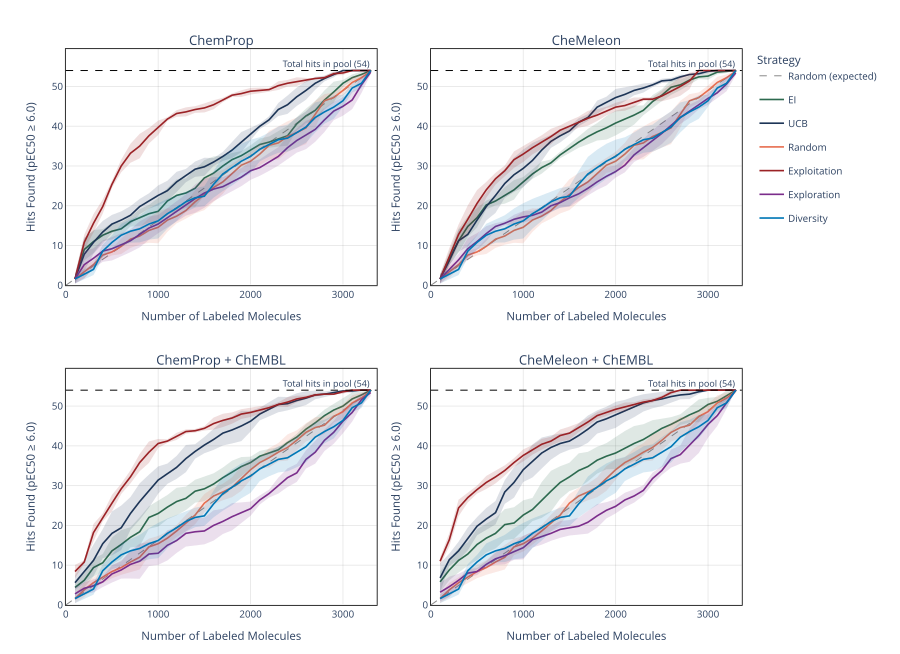

In [ ]:
content = open("demo_output/figures/pxr_combined_hit_discovery.svg").read()
orig_w = float(re.search(r'<svg[^>]*\bwidth="([^"]*)"', content).group(1))
orig_h = float(re.search(r'<svg[^>]*\bheight="([^"]*)"', content).group(1))

new_w = 900
new_h = int(orig_h * new_w / orig_w)

content = re.sub(r'(<svg[^>]*)\bwidth="[^"]*"', rf'\1width="{new_w}"', content)
content = re.sub(r'(<svg[^>]*)\bheight="[^"]*"', rf'\1height="{new_h}"', content)
SVG(data=content)

---

## Introducing `moal`: Multi-Objective Active Learning

We established that greedy exploitation works. But real campaigns have an additional complication: **not all assay data has the same fidelity.**

In a standard HTS funnel, you don't run a full dose-response curve (DRC) on every compound from the start. You run a cheap **primary screen (PS)** first — one concentration, binary answer — and only run DRCs on the hits.

| | **Primary Screen (PS)** | **Dose-Response Curve (DRC)** |
|---|---|---|
| **Method** | Single concentration (10 µM) | Full 13-point titration |
| **Result** | `"< 10 µM"` or `"≥ 10 µM"` | Exact pEC50 (e.g., 6.8) |
| **Cost** | ~$1 / compound | ~$10 / compound |

The question `moal` asks:

> **Can we use all available assay data — both primary screens AND DRCs — simultaneously to both train the model and to decide what to test next?**

Specifically:
- Primary screen **misses** (`< 10 µM`) should tell the model "this compound is probably inactive"
- Primary screen **hits** (`≥ 10 µM`) should tell the model "this compound is at least moderately active" — and become upgrade candidates for DRC
- DRC results provide exact pEC50 values for both training and evaluation

The technical challenge is that PS results are **censored** — they don't give you a point value, they give you inequality constraints. Handling this correctly requires a loss function designed for censored data.

---

## Design Assumptions

### Censored Regression (Tobit Loss)

`moal` uses a **censored regression loss** (Tobit model) that handles three types of observations:

| Label type | When it occurs | Censoring | Loss contribution |
|---|---|---|---|
| **EXACT** | DRC result | None — point observation | Standard MSE at observed pEC50 |
| **LEFT** | PS miss (`< T`) | Left-censored | Penalizes predictions above threshold T |
| **INTERVAL** | PS hit (`≥ T`) | Interval-censored: `[T, 11.0]` | Rewards predictions in the interval `[T, 11.0]` |

A critical correctness detail: **PS hits are INTERVAL-censored `[T, 11.0]`, not right-censored at T.**  
Right-censoring at T would assign high probability mass *below* T for high-pEC50 compounds — **inverting** the gradient for the most active compounds in the dataset.

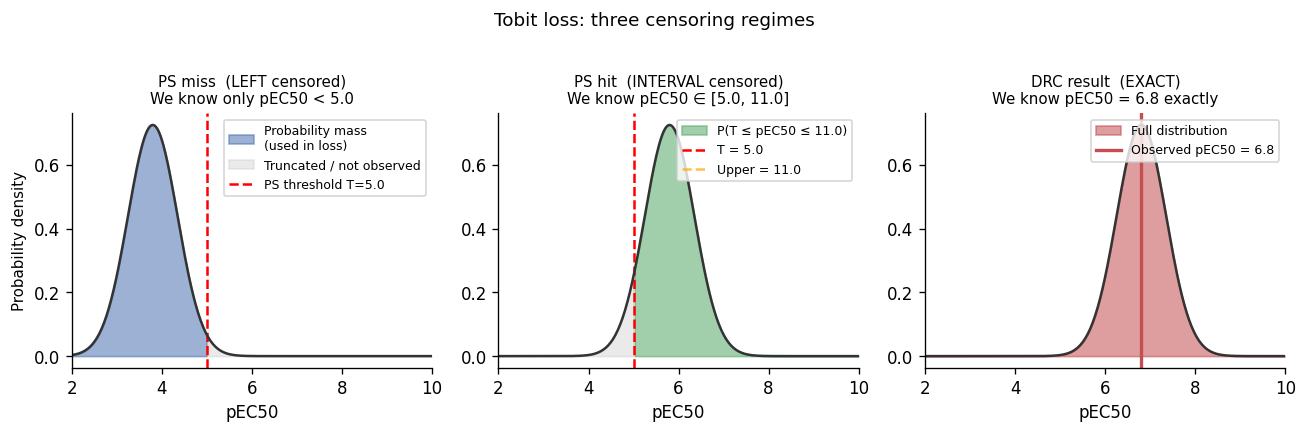

In [5]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=False)
T = 5.0
upper = 11.0
x_all = np.linspace(2, 10, 300)

for ax, (label, mu, kind) in zip(
    axes,
    [
        ("PS miss  (LEFT censored)\nWe know only pEC50 < 5.0", 3.8, "left"),
        ("PS hit  (INTERVAL censored)\nWe know pEC50 \u2208 [5.0, 11.0]", 5.8, "interval"),
        ("DRC result  (EXACT)\nWe know pEC50 = 6.8 exactly", 6.8, "exact"),
    ],
    strict=False,
):
    sigma = 0.55
    y = norm.pdf(x_all, mu, sigma)

    if kind == "left":
        ax.fill_between(
            x_all,
            0,
            y,
            where=(x_all < T),
            color="#4C72B0",
            alpha=0.55,
            label="Probability mass\n(used in loss)",
        )
        ax.fill_between(
            x_all,
            0,
            y,
            where=(x_all >= T),
            color="#CCCCCC",
            alpha=0.4,
            label="Truncated / not observed",
        )
        ax.axvline(T, color="red", lw=1.5, ls="--", label=f"PS threshold T={T}")
    elif kind == "interval":
        ax.fill_between(
            x_all,
            0,
            y,
            where=((x_all >= T) & (x_all <= upper)),
            color="#55A868",
            alpha=0.55,
            label=f"P(T \u2264 pEC50 \u2264 {upper})",
        )
        ax.fill_between(x_all, 0, y, where=(x_all < T), color="#CCCCCC", alpha=0.4)
        ax.axvline(T, color="red", lw=1.5, ls="--", label=f"T = {T}")
        ax.axvline(upper, color="orange", lw=1.5, ls="--", alpha=0.7, label=f"Upper = {upper}")
    else:
        ax.fill_between(x_all, 0, y, color="#C44E52", alpha=0.55, label="Full distribution")
        ax.axvline(mu, color="#C44E52", lw=2, label=f"Observed pEC50 = {mu}")

    ax.plot(x_all, y, color="#333333", lw=1.5)
    ax.set_xlabel("pEC50", fontsize=10)
    ax.set_ylabel("Probability density" if ax == axes[0] else "", fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.set_xlim(2, 10)

plt.suptitle("Tobit loss: three censoring regimes", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

### CheMeleon Backbone

`moal` uses **CheMeleon** as its molecular encoder — a graph neural network pretrained on millions of molecules. CheMeleon provides:

- **Transferable representations** that generalize even from small labeled sets (important in early AL iterations)
- **Frozen encoder** for the first few epochs per iteration (prevents overfitting on tiny pools), then **fine-tuned end-to-end**

### Three Distinct Thresholds

These are often confused. They serve completely different purposes:

| Parameter | Role | Typical value |
|---|---|---|
| `oracle.ps_threshold` = `acquisition.ps_threshold` | The assay's biological cutoff — where the PS reports `<` vs `≥`. Must match in both sections. | 5.0 (10 µM) |
| `acquisition.target_threshold` | What "worth a full DRC" means — the center of the DRC exploitation sigmoid | 6.5 (316 nM) |
| `oracle.activity_threshold` | What counts as a confirmed **active** for campaign evaluation | 6.0 (1 µM, for PXR) |

### Plate Budget

Selection stops when the **next query would overflow `plate_size` wells** — not when a compound count is reached.

```
plate_size = 1536 wells
wells per DRC = 13  →  max ~118 DRC per plate
wells per PS  = 1   →  max 1536 PS per plate
```

A mixed plate (some DRC, some PS) gets the best of both worlds: exploit high-confidence predictions with DRC, explore borderline compounds cheaply with PS.

---

## The Selection Heuristic

`moal` uses a **unified cost-aware scoring** approach. Every candidate compound (whether unqueried or a PS hit awaiting upgrade) receives up to two scores — one for each possible next action — in the same unit: **information per dollar**.

### DRC score — exploitation

$$\text{score\_DRC}(x) = \frac{\sigma\!\left(\frac{\hat{y} - \text{target\_threshold}}{\tau}\right)}{\text{cost\_DRC}} = \frac{p_\text{active}(x)}{\text{cost\_DRC}}$$

This is **expected-active probability per dollar**. It is maximized when the model predicts $\hat{y}$ well above `target_threshold`.

### PS score — threshold exploration

$$\text{score\_PS}(x) = \frac{H_\text{binary}\!\left(\sigma\!\left(\frac{\hat{y} - \text{ps\_threshold}}{\tau}\right)\right)}{\text{cost\_PS}}$$

This is **binary entropy of the threshold-crossing probability per dollar**. It is maximized when $\hat{y} \approx \text{ps\_threshold}$, i.e., when the model is maximally uncertain whether the compound clears the primary screen cutoff. At both extremes ($\hat{y}$ clearly above or below the threshold), H → 0 and score → 0.

### The unified ranked list

Both scores share the same unit, so they compete on a single sorted list. The greedy procedure pops entries (skipping compounds already chosen) until the plate budget is exhausted.

**PS-INTERVAL compounds** (PS hits awaiting upgrade) contribute only a DRC score — the acquisition can upgrade them to a full DRC, but re-running the PS makes no sense.

This naturally produces a **two-phase behavior**:
- **Early iterations** (model uncertain, predictions clustered near 6.0): PS dominates — broad, cheap exploration
- **Late iterations** (model sharp, actives identified): DRC dominates — exploit high-confidence predictions and upgrade PS hits

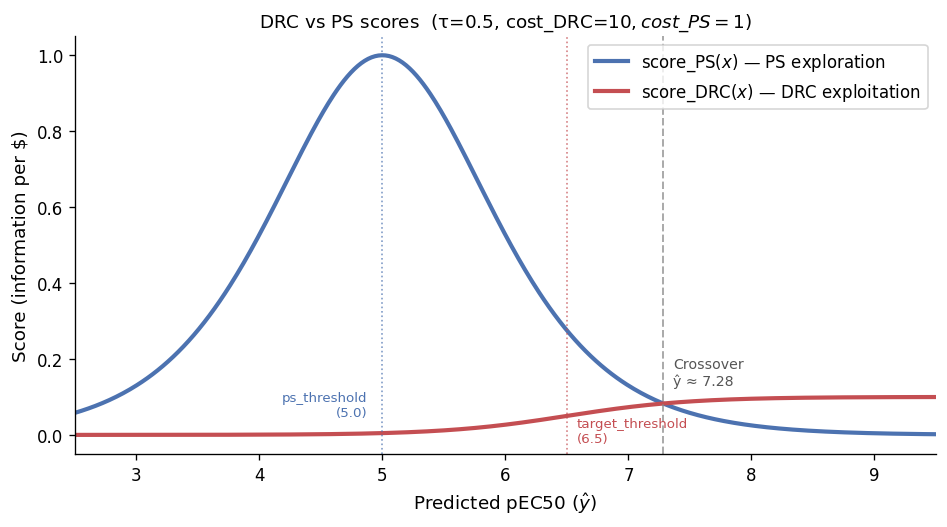

Crossover point: ŷ ≈ 7.28 pEC50
Below this: PS is preferred (cheap exploration near threshold)
Above this: DRC is preferred (exploit likely actives)


In [24]:
def sigmoid(x):  # noqa: D103
    return 1 / (1 + np.exp(-x))


def h_binary(p):  # noqa: D103
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)


pec50 = np.linspace(2.5, 9.5, 500)
ps_threshold = 5.0
target_threshold = 6.5
tau = 0.5
cost_ps = 1.0
cost_drc = 10.0

score_drc = sigmoid((pec50 - target_threshold) / tau) / cost_drc
score_ps = h_binary(sigmoid((pec50 - ps_threshold) / tau)) / cost_ps

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(pec50, score_ps, lw=2.5, color="#4C72B0", label=r"$\mathrm{score\_PS}(x)$ — PS exploration")
ax.plot(
    pec50, score_drc, lw=2.5, color="#C44E52", label=r"$\mathrm{score\_DRC}(x)$ — DRC exploitation"
)

cross_mask = pec50 > ps_threshold
cross_idx = np.argmin(np.abs(score_ps[cross_mask] - score_drc[cross_mask]))
cross_x = pec50[cross_mask][cross_idx]
cross_y = score_drc[cross_mask][cross_idx]
ax.axvline(cross_x, color="#888888", lw=1.2, ls="--", alpha=0.7)
ax.text(
    cross_x + 0.08,
    cross_y + 0.05,
    f"Crossover\n\u0177 \u2248 {cross_x:.2f}",
    fontsize=8.5,
    color="#555555",
)

ax.axvline(ps_threshold, color="#4C72B0", lw=1.0, ls=":", alpha=0.7)
ax.text(
    ps_threshold - 0.12,
    score_ps.max() * 0.05,
    f"ps_threshold\n({ps_threshold})",
    fontsize=8,
    color="#4C72B0",
    ha="right",
)
ax.axvline(target_threshold, color="#C44E52", lw=1.0, ls=":", alpha=0.7)
ax.text(
    target_threshold + 0.08,
    -0.02,
    f"target_threshold\n({target_threshold})",
    fontsize=8,
    color="#C44E52",
)

ax.set_xlabel("Predicted pEC50 ($\\hat{y}$)", fontsize=11)
ax.set_ylabel("Score (information per $)", fontsize=11)
ax.set_title(
    f"DRC vs PS scores  (\u03c4={tau}, cost_DRC=${cost_drc:.0f}, cost\\_PS=${cost_ps:.0f})",
    fontsize=11,
)
ax.legend(fontsize=10)
ax.set_xlim(2.5, 9.5)
plt.tight_layout()
plt.show()

print(f"Crossover point: \u0177 \u2248 {cross_x:.2f} pEC50")
print("Below this: PS is preferred (cheap exploration near threshold)")
print("Above this: DRC is preferred (exploit likely actives)")

---

## The PXR Dataset

We'll demo `moal` on a real dataset: the **Pregnane X Receptor (PXR)** compound library assembled by Octant Bio and released as part of a [blind prediction challenge](https://openadmet.ghost.io/predicting-pxr-induction-we-have-liftoff/).

PXR is a nuclear receptor that acts as the body's primary xenobiotic sensor. When a drug molecule binds PXR, it upregulates CYP3A4, accelerating metabolic clearance of co-administered therapies and causing drug-drug interactions (DDIs). PXR binding affinity is therefore a critical **ADMET antitarget** — you want to flag it early in drug design.

The pool comprises **4,140 compounds** from an Enamine diversity deck — a maximally structurally diverse selection designed to cover chemical space broadly. With only 67 confirmed actives (pEC50 ≥ 6.0, or ~1 µM), this is a challenging sparse hit-finding problem: a random strategy would take a long time to find them all.

PXR dataset: 4,140 compounds
pEC50 range: 1.61 – 7.55
Actives (pEC50 ≥ 6.0): 67 (1.6%)


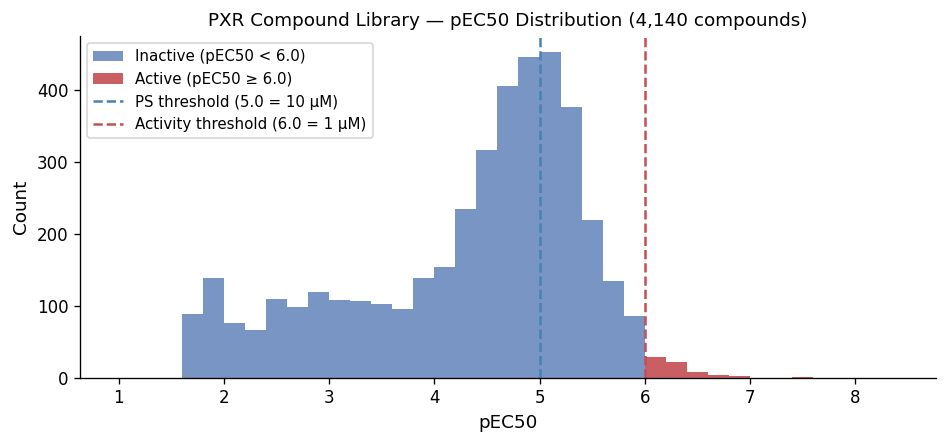

In [26]:
data_path = DATA_DIR / "pxr_data.csv"
df_pxr = pd.read_csv(data_path)
print(f"PXR dataset: {len(df_pxr):,} compounds")
print(f"pEC50 range: {df_pxr['value'].min():.2f} – {df_pxr['value'].max():.2f}")
print(
    f"Actives (pEC50 \u2265 6.0): {(df_pxr['value'] >= 6.0).sum()} "
    f"({(df_pxr['value'] >= 6.0).mean() * 100:.1f}%)"
)

fig, ax = plt.subplots(figsize=(8, 3.8))
bins = np.arange(1.0, 8.5, 0.2)
inactive_mask = df_pxr["value"] < 6.0
active_mask = df_pxr["value"] >= 6.0

ax.hist(
    df_pxr.loc[inactive_mask, "value"],
    bins=bins,
    color="#4C72B0",
    alpha=0.75,
    label="Inactive (pEC50 < 6.0)",
)
ax.hist(
    df_pxr.loc[active_mask, "value"],
    bins=bins,
    color="#C44E52",
    alpha=0.9,
    label="Active (pEC50 \u2265 6.0)",
)

ax.axvline(5.0, color="steelblue", lw=1.5, ls="--", label="PS threshold (5.0 = 10 \u00b5M)")
ax.axvline(6.0, color="#C44E52", lw=1.5, ls="--", label="Activity threshold (6.0 = 1 \u00b5M)")

ax.set_xlabel("pEC50", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("PXR Compound Library \u2014 pEC50 Distribution (4,140 compounds)", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---

## Running `moal simulate`

`moal simulate` runs a virtual active learning campaign over a fixed compound pool whose true pEC50 values are known. It simulates the full multi-iteration loop: train → select → "assay" (look up oracle ground truth) → retrain → repeat.

**Why simulate?**
- Tune `n_iterations`, `plate_size`, `tau`, thresholds *before* spending real money
- Benchmark your specific compound pool and target
- Validate that your config produces sensible PS/DRC ratios

We configure the campaign with:
- **Pool:** 4,140 PXR compounds, 15% scaffold-split held out as test set
- **20 iterations** of up to 1536 wells each
- **PS threshold:** 5.0 (10 µM), **activity threshold:** 6.0 (1 µM)
- **Fast surrogate mode** (`model.fast: true`) by default — swap to `false` for real CheMeleon results

> **Cache note:** If `demo_output/simulate_results/iteration_metrics.csv` already exists (e.g., from a pre-run full CheMeleon campaign), the cell below loads those results instead of running the simulation.

In [27]:
SIM_METRICS = SIM_OUT / "iteration_metrics.csv"
SIM_CURVE = SIM_OUT / "cumulative_actives_curve.csv"
SIM_CONFIG = EXAMPLES / "demo_simulate_config.yaml"

print(f"Config : {SIM_CONFIG}")
print(f"Output : {SIM_OUT}")

Config written to: /Users/smcolby/repos/moal/examples/demo_output/simulate_results/simulate_config.yaml


In [28]:
print("Command:")
print("  moal simulate --config demo_simulate_config.yaml")
print()

if SIM_METRICS.exists() and SIM_CURVE.exists():
    print("✓ Cache found — loading pre-computed results.")
    print("  (Delete demo_output/simulate_results/ to re-run.)")
else:
    !cd {EXAMPLES} && moal simulate --config demo_simulate_config.yaml

metrics_df = pd.read_csv(SIM_METRICS)
curve_df = pd.read_csv(SIM_CURVE)
print(f"\nLoaded: {len(metrics_df)} iterations, {len(curve_df)} labeled records")

✓ Cache found — loading pre-computed simulate results.
  (Delete demo_output/simulate_results/ to re-run.)

Loaded: 15 iterations, 5462 labeled records


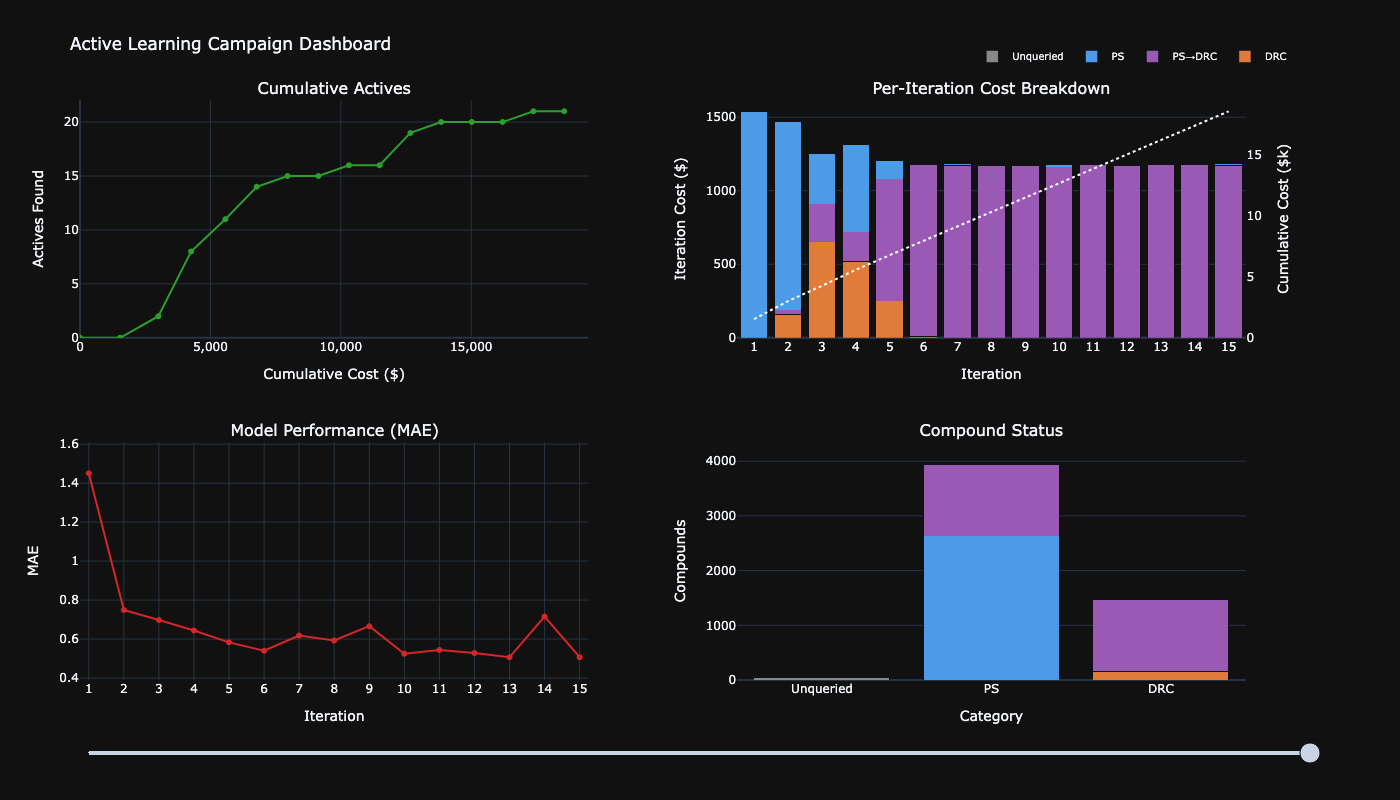

In [60]:
Image("demo_output/figures/dashboard.png", width=900)

**Hit-discovery curve (Panel 1):** `moal`'s exploitation strategy recovers actives much faster than random sampling. The curve steepens early, as the model quickly identifies the high-pEC50 region of chemical space and concentrates queries there.

**Cost breakdown (Panel 2):** Notice the natural phase transition:
- **Early iterations** (model noisy, predictions spread around 6.0): PS queries dominate — cheap exploration is the rational choice
- **Later iterations** (model sharp, clear actives identified): DRC queries (and PS→DRC upgrades) take over — the model is confident enough to justify the 10× cost premium

This phase transition **emerges automatically** from the score formulas — no explicit scheduling is needed.

**PS→DRC upgrades:** Some PS hits (compounds that cleared the PS threshold) get automatically promoted to DRC queries in later iterations. This mirrors the standard two-stage HTS funnel, but driven by the model's confidence rather than manual curation.

**Fast vs. real-model results:** The surrogate model (`model.fast: true`) uses the oracle's true pEC50 values with added noise, so it provides a *best-case envelope* for what a perfect model could achieve. Real CheMeleon results will be slightly below this curve but follow the same qualitative pattern.

---

## Running `moal plan`

`moal plan` solves a different problem: **you're mid-campaign (or just starting) and need next-plate recommendations.**

You have:
- Some PS results (misses and hits) from previous plates
- Some DRC results from follow-up experiments
- A large number of compounds that have never been tested

`moal plan` trains on your mixed-fidelity labeled pool, predicts pEC50 for everything untested, scores each compound with the same DRC/PS heuristic, and outputs a ranked list with a `recommendation` column (`"ps"` or `"drc"`).

### Campaign state CSV format

The input is a single unified CSV with these columns:

| Column | Value | Meaning |
|---|---|---|
| `smiles` | SMILES string | Compound structure |
| `relation` | `""` (empty) | Unqueried — eligible for PS or DRC |
| `relation` | `"<"` | PS miss: pEC50 < ps_threshold |
| `relation` | `">="` | PS hit: pEC50 ≥ ps_threshold (upgrade candidate) |
| `relation` | `"=="` | DRC result: exact pEC50 known |
| `value` | pEC50 or `""` | Observed value (empty for unqueried rows) |

Let's build a realistic partial campaign state from the PXR dataset.

In [30]:
import random

random.seed(42)
np.random.seed(42)

df_all = df_pxr.copy().reset_index(drop=True)

# 70% unqueried, 30% queried via PS
unqueried_idx = df_all.sample(frac=0.70, random_state=42).index
queried_df = df_all.drop(unqueried_idx).reset_index(drop=True)

# PS result: miss if pEC50 < 5.0, hit otherwise
queried_df["relation_ps"] = np.where(queried_df["value"] < 5.0, "<", ">=")

# ~40% of PS hits also got DRC follow-up
ps_hits = queried_df[queried_df["relation_ps"] == ">="].copy()
drc_idx = ps_hits.sample(frac=0.40, random_state=7).index
drc_df = queried_df.loc[drc_idx].copy()
ps_only = queried_df[~queried_df.index.isin(drc_idx)].copy()

rows = []
for _, row in df_all.loc[unqueried_idx].iterrows():
    rows.append({"smiles": row["smiles"], "relation": "", "value": ""})
for _, row in ps_only.iterrows():
    rows.append({"smiles": row["smiles"], "relation": row["relation_ps"], "value": 5.0})
for _, row in drc_df.iterrows():
    rows.append({"smiles": row["smiles"], "relation": "==", "value": row["value"]})

campaign_df = pd.DataFrame(rows)
CAMPAIGN_CSV = PLAN_OUT / "campaign_state.csv"
campaign_df.to_csv(CAMPAIGN_CSV, index=False)

print("Campaign state summary:")
print(f"  Unqueried:   {(campaign_df['relation'] == '').sum():>5,}")
print(f"  PS miss (<): {(campaign_df['relation'] == '<').sum():>5,}")
print(f"  PS hit (>=): {(campaign_df['relation'] == '>=').sum():>5,}")
print(f"  DRC (==):    {(campaign_df['relation'] == '==').sum():>5,}")
print(f"  Total:       {len(campaign_df):>5,}")
print(f"\nSaved to: {CAMPAIGN_CSV}")

Campaign state summary:
  Unqueried:   2,898
  PS miss (<):   850
  PS hit (>=):   235
  DRC (==):      157
  Total:       4,140

Saved to: /Users/smcolby/repos/moal/examples/demo_output/plan_results/campaign_state.csv


In [31]:
PLAN_ANNOTATED = PLAN_OUT / "campaign_state_annotated.csv"
PLAN_CONFIG = EXAMPLES / "demo_plan_config.yaml"

print(f"Config : {PLAN_CONFIG}")
print(f"Output : {PLAN_OUT}")

Plan config written to: /Users/smcolby/repos/moal/examples/demo_output/plan_results/plan_config.yaml


In [32]:
print("Command:")
print("  moal plan --config demo_plan_config.yaml")
print()

if PLAN_ANNOTATED.exists():
    print("✓ Cache found — loading pre-computed results.")
    print("  (Delete demo_output/plan_results/campaign_state_annotated.csv to re-run.)")
else:
    print("Running moal plan (CheMeleon, 5 epochs) — ~2–5 min on CPU ...")
    !cd {EXAMPLES} && moal plan --config demo_plan_config.yaml

annotated = pd.read_csv(PLAN_ANNOTATED)
print(f"\nAnnotated CSV: {len(annotated):,} rows")
print("Columns:", annotated.columns.tolist())

✓ Cache found — loading pre-computed plan results.
  (Delete demo_output/plan_results/campaign_state_annotated.csv to re-run.)

Annotated CSV: 4,140 rows
Columns: ['smiles', 'relation', 'value', 'ps_score', 'drc_score', 'overall_score', 'recommendation']


In [33]:
top = annotated.dropna(subset=["overall_score"]).head(20)

print("=== Top 20 Recommendations for Next Plate ===\n")
display_cols = [
    "smiles",
    "relation",
    "value",
    "recommendation",
    "ps_score",
    "drc_score",
    "overall_score",
]
display_cols = [c for c in display_cols if c in top.columns]

pd.set_option("display.max_colwidth", 28)
pd.set_option("display.float_format", "{:.4f}".format)
print(top[display_cols].to_string(index=False))

rec_counts = annotated["recommendation"].value_counts()
print("\nRecommendation summary:")
for rec, n in rec_counts.items():
    print(f"  {rec:>4}: {n:,}")

=== Top 20 Recommendations for Next Plate ===

                                                                     smiles relation  value recommendation  ps_score  drc_score  overall_score
                       CC1=CC=C(C2CC(C)N(S(=O)(=O)CC3=CC=CC(C#N)=C3)C2)C=C1      NaN    NaN             ps    0.6931     0.0119         0.6931
                              CC1=CC=C2CCC[C@@H](NC(=O)C3=CC=C(C)N=N3)C2=C1      NaN    NaN             ps    0.6931     0.0119         0.6931
                                 CC1=CC=C(CN(C(=O)C2=NC=C(F)C=N2)C(C)C)C=C1      NaN    NaN             ps    0.6931     0.0119         0.6931
                               CCCC1(COC)CCCN1C(=O)C1=C(C)C=C(S(N)(=O)=O)S1      NaN    NaN             ps    0.6931     0.0119         0.6931
                             CC(C)(C)OCC1=CC=CC(NC(=O)C2=C3C=CC=NN3N=C2)=C1      NaN    NaN             ps    0.6931     0.0119         0.6931
                              FC(F)(F)C1=CC=C(N2CCC[C@H]2COC2=CC=CC=C2)N=N1      NaN    NaN    

---

## Summary & Next Steps

### What `moal` provides

`moal` is a simple, principled, and practical active learning system for drug discovery. Its core idea:

> **Use all available assay data — cheap primary screens and expensive DRCs together — both to train the model and to decide what to assay next, with the decision driven by a single unified cost-aware score.**

No uncertainty modeling. No ensemble committees. Just a well-calibrated exploitation signal, a cost-conscious secondary exploration term for PS queries, and a training objective that treats censored data correctly.

### When to use `moal simulate`

Use `moal simulate` when you want to:
- **Benchmark** your config before spending real money
- **Tune** `tau`, `target_threshold`, `plate_size`, or `n_iterations` for your specific target
- **Compare** strategies or configs on a previously-run dataset
- **Estimate** expected recall curves and cost-to-hit ratios

### When to use `moal plan`

Use `moal plan` when you:
- Are **mid-campaign** and want model-driven recommendations for the next plate
- Have a **CSV of current campaign state** (some PS results, some DRCs, many unqueried)
- Want to **decide** for each unqueried compound: primary screen first, or go straight to DRC?

### Going beyond fast mode

The demo above uses `model.fast: true` (surrogate mode) for `simulate` to keep runtime short. For production use:

```yaml
model:
  fast: false
  freeze_epochs: 2
  lr_encoder: 1.0e-4
  lr_head: 1.0e-3
trainer:
  max_epochs: 30
```

This trains CheMeleon on your labeled pool at each iteration. Expect 5–30 minutes per iteration on CPU, or 1–5 minutes on GPU.